<div style="border-left: 6px solid #00356B; padding-left: 15px; margin-bottom: 20px;">
  <h1 style="margin-bottom: 5px; color: #00356B"><strong>Final Project:</strong> Utility-Constrained Causal Serendipity Recommender System</h1>
  <span style="font-size: 1.2em; color: #444; font-weight: bold">S&DS 5350 | Social Algorithms</span>
  <br><br>
  <strong>Primary:</strong> Cailey Bobadilla (cjb239)
  <br>
  <strong>Partner :</strong> Brandon Tran (bat53)
  <br>
  <strong>Group:</strong> 9
</div>

---

*Mood for this part:*

<iframe data-testid="embed-iframe" style="border-radius:12px" src="https://open.spotify.com/embed/track/5TdrCQVt3l1uEz3pFdTgXC?utm_source=generator" width="40%" height="152" frameBorder="0" allowfullscreen="" allow="autoplay; clipboard-write; encrypted-media; fullscreen; picture-in-picture" loading="lazy"></iframe>

**Dataset:** Last.fm HetRec 2011
(CITATION)

This notebook imports the pipeline defined in `serendipity_pipeline.py` and uses it to run the full four-stage algorithm, then produces analysis and visualizations at each stage. Additionally, a sensitivity analysis over $\alpha$ and confidence scaling mode (linear vs. log) is conducted prior to Stage 2 to justify the final hyperparameter choice.

| Stage | Method | Output |
| --- | --- | --- |
| 1 | Hierarchical Poisson Factorization on binary exposure matrix $A$ | $\hat a_{ui}$: natural exposure probability |
| - | Sensitivity analysis over $\alpha$ and scaling mode (linear vs. log) | $\alpha = 10$, mode = linear |
| 2 | Causal LMF with substitude confounder injected | $\theta_u$, $\beta_i$: unconfounded preference vectors |
| 3 | Empirical $q_t$ estimation + inverse_weight slot allocation | $n_t$: slots per category |
| 4 | Serendipity scoring + slate assembly + comparison against baseline and listening history | Final top-$N$ slate |

**AI Acknowledgement:**
- Claude Sonnet 4.6

### Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Import all functions and constants from the pipeline library
from serendipity_pipeline import (
    # Constants
    DATA_DIR, ALPHA, TAU_C, TAU_R, EPSILON, N_SLOTS,
    N_FACTORS, N_ITER, TOP_K_TAGS,
    # Functions
    load_data,
    build_matrices,
    fit_poisson_factorization,
    CausalLMF,
    build_artist_categories,
    compute_qt,
    allocate_slots,
    compute_serendipity_scores,
    build_slate,
)

# Notebook display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
FIGSIZE = (10, 4)
 
print('Imports successful.')

Imports successful.


### Data Loading and Exploration

In [2]:
ua, artists, tags, uta, user2idx, item2idx, n_users, n_items = load_data(DATA_DIR)

Loaded: 1892 users, 17632 artists, 92834 interactions


In [3]:
# Preview the core interaction file
print('user_artists.dat (first 5 rows)')
display(ua[['userID', 'artistID', 'weight', 'u', 'i']].head())
 
print('\nListen-count summary (r_ui)')
display(ua['weight'].describe().rename('r_ui').to_frame())

user_artists.dat (first 5 rows)


,userID,artistID,weight,u,i
0,2,51,13883,0,45
1,2,52,11690,0,46
2,2,53,11351,0,47
3,2,54,10300,0,48
4,2,55,8983,0,49



Listen-count summary (r_ui)


,r_ui
count,92834.0000
mean,745.2439
std,3751.3221
min,1.0000
25%,107.0000
50%,260.0000
75%,614.0000
max,352698.0000


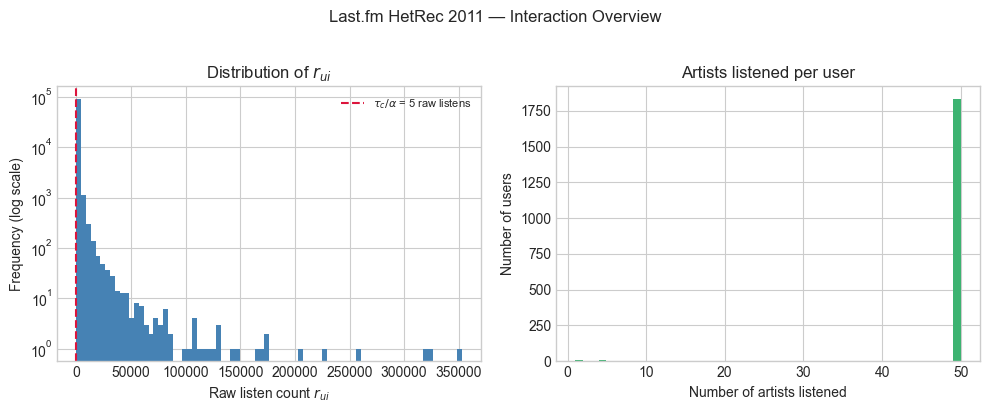

In [4]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
 
# Left: distribution of raw listen counts (log scale)
# NOTE: Red dashed line marks the implied tau_c / alpha threshold in raw-count
#       space (minimum listens needed to count as a "satisfying" interaction)
axes[0].hist(ua['weight'], bins=80, color='steelblue', edgecolor='none', 
             log=True)
axes[0].axvline(TAU_C / ALPHA, color='crimson', linestyle='--', 
                label=f'$\\tau_c / \\alpha$ = {TAU_C // ALPHA} raw listens')
axes[0].set_xlabel('Raw listen count $r_{ui}$')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Distribution of $r_{ui}$')
axes[0].legend(fontsize=8)
 
# Right: number of artists listened per user
user_counts = ua.groupby('userID')['artistID'].count()
axes[1].hist(user_counts, bins=50, color='mediumseagreen', edgecolor='none')
axes[1].set_xlabel('Number of artists listened')
axes[1].set_ylabel('Number of users')
axes[1].set_title('Artists listened per user')
 
plt.suptitle('Last.fm HetRec 2011 — Interaction Overview', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# Top-10 most-listened artists globally
top_artists = (
    ua.groupby('artistID')['weight']
    .sum()
    .reset_index()
    .merge(artists[['artistID', 'name']], on='artistID')
    .sort_values('weight', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_artists.index += 1
top_artists.index.name = 'rank'
 
print('Top-10 most-listened artists (total listens across all users):')
display(top_artists[['name', 'weight']].rename(columns={'weight': 'total_listens'}))

Top-10 most-listened artists (total listens across all users):


,name,total_listens
rank,,
1,Britney Spears,2393140
2,Depeche Mode,1301308
3,Lady Gaga,1291387
4,Christina Aguilera,1058405
5,Paramore,963449
6,Madonna,921198
7,Rihanna,905423
8,Shakira,688529
9,The Beatles,662116


### Matrix Construction

Three sparse matrices built from `user_artists.dat`:

| Matrix | Definition | Role |
| --- | --- | --- |
| $R$ | $r_{ui}$ = raw listen count | Reference |
| $C$ | $c_{ui} = \alpha \cdot r_{ui}$ | Confidence weights for LMF |
| $A$ | $a_{ui} = \mathbb{1}[r_{ui} > 0]$ | Binary exposure / treatment assignment |

In [6]:
R, _, A = build_matrices(ua, n_users, n_items)

Sparsity: 99.72%


### Stage 1: Exposure Modeling (Poisson Factorization)

HPF is fit to the binary matrix $A$ to model the confounding mechanism driving organic discovery. The output $\hat a_{ui}$ estimates the probability user $u$ would naturally encounter artist $i$ without algorithmic intervention. 

In [7]:
pf_model, a_hat = fit_poisson_factorization(A, n_factors=N_FACTORS)
 
# Save a_hat so Stage 2 can be re-run without repeating Stage 1
np.save('a_hat.npy', a_hat)
print('Saved: a_hat.npy')

**********************************
Hierarchical Poisson Factorization
**********************************

Number of users: 1892
Number of items: 17632
Latent factors to use: 20

Initializing parameters...
Allocating Phi matrix...
Initializing optimization procedure...
Iteration 10 | train llk: -480209 | train rmse: 0.9493
Iteration 20 | train llk: -407018 | train rmse: 0.8947
Iteration 30 | train llk: -402045 | train rmse: 0.8904
Iteration 40 | train llk: -400244 | train rmse: 0.8891
Iteration 50 | train llk: -399468 | train rmse: 0.8885
Iteration 60 | train llk: -399032 | train rmse: 0.8882
Iteration 70 | train llk: -398661 | train rmse: 0.8879
Iteration 80 | train llk: -398480 | train rmse: 0.8878
Iteration 90 | train llk: -398378 | train rmse: 0.8878
Iteration 100 | train llk: -398245 | train rmse: 0.8877


Optimization finished
Final log-likelihood: -398245
Final RMSE: 0.8877
Minutes taken (optimization part): 0.1

a_hat range: [0.0000, 1.0000]
a_hat std: 0.0161
Saved: a_hat.npy


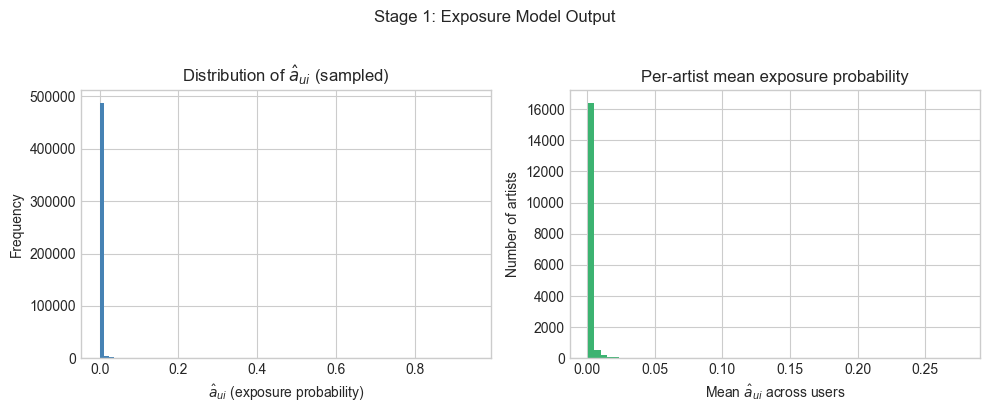

Mean a_hat: 0.0026
Median a_hat: 0.0008


In [8]:
# EXPOSURE PROBABILITY ANALYSIS

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
 
# Sample to keep plotting fast
rng = np.random.default_rng(0)
sample = rng.choice(a_hat.flatten(),
                    size=min(500_000, a_hat.size), replace=False)
 
# Left: overall a_hat distribution
axes[0].hist(sample, bins=80, color='steelblue', edgecolor='none')
axes[0].set_xlabel('$\\hat{a}_{ui}$ (exposure probability)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of $\\hat{a}_{ui}$ (sampled)')
 
# Right: mean exposure per artist (popularity proxy)
item_exposure = a_hat.mean(axis=0)
axes[1].hist(item_exposure, bins=60, color='mediumseagreen', edgecolor='none')
axes[1].set_xlabel('Mean $\\hat{a}_{ui}$ across users')
axes[1].set_ylabel('Number of artists')
axes[1].set_title('Per-artist mean exposure probability')
 
plt.suptitle('Stage 1: Exposure Model Output', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
 
print(f'Mean a_hat: {a_hat.mean():.4f}')
print(f'Median a_hat: {np.median(a_hat):.4f}')

### Sensitivity Analysis: Choosing $\alpha$ and Mode

In [9]:
# BASELINE COMPARISON: Standard LMF vs Causal LMF
from scipy.sparse import csr_matrix

class StandardLMF:
    """
    Standard Logistic Matrix Factorization without causal debiasing.

    Identical to CausalLMF in architecture and training procedure, but
    omits the substitute confounder term entirely. The prediction is:
        p(l_ui) = sigmoid(theta_u @ beta_i)

    Because the exposure signal never enters training, the learned latent
    vectors conflate genuine preference with organic discoverability. Used
    as a baseline to verify that the causal injection in CausalLMF
    meaningfully decorrelates preference scores from exposure probability.
    """

    def __init__(self, n_users, n_items, n_factors=N_FACTORS, n_iter=N_ITER,
                 lr=0.01, reg=0.01, random_state=42, init_Theta=None,
                 init_Beta=None):
        """
        Initializes the StandardLMF model parameters.

        Args:
            n_users (int): Number of users in the dataset.
            n_items (int): Number of items (artists) in the dataset.
            n_factors (int): Number of latent dimensions. Defaults to
                             N_FACTORS.
            n_iter (int): Number of alternating gradient ascent iterations.
                          Defaults to N_ITER.
            lr (float): Learning rate for all parameter updates. Defaults
                        to 0.01.
            reg (float): L2 regularization coefficient applied to Theta and
                         Beta. Defaults to 0.01.
            random_state (int): Seed for reproducibility. Defaults to 42.
            init_Theta (np.ndarray or None): Optional pre-trained user latent
                                             matrix of shape
                                             (n_users, n_factors) for a warm
                                             start. Defaults to None.
            init_Beta (np.ndarray or None): Optional pre-trained item latent
                                            matrix of shape
                                            (n_items, n_factors) for a warm
                                            start. Defaults to None.
        """
        self.n_users = n_users
        self.n_items = n_items
        self.n_factors = n_factors
        self.n_iter = n_iter
        self.lr = lr
        self.reg = reg
        rng = np.random.default_rng(random_state)
        scale = 0.01

        # Warm-start from PF latent factors if provided, identical to
        # CausalLMF to ensure a fair comparison between the two models
        if init_Theta is not None and init_Beta is not None:
            self.Theta = init_Theta.copy()   # shape: (n_users, n_factors)
            self.Beta = init_Beta.copy()     # shape: (n_items, n_factors)
        else:
            self.Theta = rng.normal(0, scale, (n_users, n_factors))
            self.Beta = rng.normal(0, scale, (n_items, n_factors))

    @staticmethod
    def sigmoid(x):
        """
        Numerically stable sigmoid function.

        Uses the same piecewise implementation as CausalLMF to ensure
        numerical consistency between the two models.

        Args:
            x (np.ndarray): Input array of any shape.

        Returns:
            np.ndarray: Element-wise sigmoid of x, in the range (0, 1).
        """
        x = np.clip(x, -500, 500)
        return np.where(x >= 0, 1 / (1 + np.exp(-x)), np.exp(x) / (1 + np.exp(x)))

    def fit(self, C: csr_matrix):
        """
        Trains the standard LMF via full-batch alternating gradient ascent.

        Mirrors the CausalLMF training loop exactly, except that no Gamma
        term is present and a_hat is never used. This ensures that any
        difference in learned representations between the two models is
        attributable solely to the causal injection, not to differences in
        architecture or optimization.

        Args:
            C (csr_matrix): Sparse confidence matrix of shape (n_users,
                            n_items). C[u, i] = alpha * r_ui.

        Returns:
            self: The fitted StandardLMF instance.
        """
        # Convert to dense for vectorized operations, identical to CausalLMF
        C_dense = np.array(C.todense())

        # Binary preference indicator: 1 if any interaction exists, else 0
        P = (C_dense > 0).astype(float)

        for iteration in range(self.n_iter):

            # Step 1: Update Theta (Beta fixed)

            # Scores are purely the dot product — no exposure term
            scores = self.Theta @ self.Beta.T
            probs = self.sigmoid(scores)

            # Confidence-weighted residuals, same as CausalLMF
            errors = C_dense * (P - probs)   # shape: (n_users, n_items)

            grad_theta = errors @ self.Beta - self.reg * self.Theta
            self.Theta += self.lr * grad_theta

            # Step 2: Update Beta (Theta fixed)

            # Recompute scores with updated Theta
            scores = self.Theta @ self.Beta.T
            probs = self.sigmoid(scores)
            errors = C_dense * (P - probs)

            grad_beta = errors.T @ self.Theta - self.reg * self.Beta
            self.Beta += self.lr * grad_beta

            if (iteration + 1) % 5 == 0:
                print(f'  Iter {iteration+1}/{self.n_iter}')

        return self

    def predict(self, u: int) -> np.ndarray:
        """
        Returns preference scores for all items for user u.

        Unlike CausalLMF.predict_unconfounded(), no Gamma term needs to be
        dropped here because the model was never trained with one. The scores
        therefore reflect a conflation of genuine preference and exposure bias.

        Args:
            u (int): Zero-indexed target user index.

        Returns:
            np.ndarray: 1D array of shape (n_items,) with preference scores
                        for every item.
        """
        return self.Theta[u] @ self.Beta.T

In [10]:
def build_baseline_slate(u, model, a_hat, A, artists, item2idx, N_SLOTS=10):
    """
    Assembles a recommendation slate based on the Standard LMF baseline.
    
    This function ranks items purely by their confounded preference scores 
    (theta_u @ beta_i), which represents the model's estimate of user preference 
    without accounting for exposure bias. It masks items the user has already 
    interacted with.

    Args:
        u (int): Zero-indexed target user ID.
        model (object): Trained baseline Logistic Matrix Factorization model.
        a_hat (np.ndarray): Predicted exposure probability matrix of shape 
                            (n_users, n_items).
        A (scipy.sparse.csr_matrix): Binary interaction/exposure matrix used 
                                     to mask items the user has already seen.
        artists (pd.DataFrame): Metadata containing 'artistID' and 'name' 
                                columns.
        item2idx (dict): Mapping of original artist IDs to zero-indexed item 
                         indices.
        N_SLOTS (int, optional): The number of recommendations to include in 
                                 the slate. Defaults to 10.

    Returns:
        pd.DataFrame: Contains the recommendation slate with the columns:
            - 'artist': The human-readable name of the artist.
            - 'confounded_pref': The raw preference score from the baseline model.
            - 'exposure_prob': The estimated probability of the user discovering 
              this item naturally (a_hat).
            The DataFrame is indexed from rank 1 to N_SLOTS.
    """
    # Get confounded scores for all items
    scores = model.predict(u)
    
    # Mask items the user has already listened to
    # NOTE: Flattens the sparse row to a 1D array to identify seen items
    observed_mask = np.array(A[u].todense()).flatten() > 0
    scores[observed_mask] = -np.inf
    
    # Identify Top-N items by score
    top_indices = np.argsort(scores)[::-1][:N_SLOTS]
    idx2item = {v: k for k, v in item2idx.items()}
    
    slate_data = []
    for item_idx in top_indices:
        artist_id = idx2item[item_idx]
        name_series = artists.loc[artists['artistID'] == artist_id, 'name']
        
        artist_name = (name_series.values[0]
                       if len(name_series) > 0 else f'Artist_{artist_id}')
        
        slate_data.append({
            'artist': artist_name,
            'confounded_pref': scores[item_idx],
            'exposure_prob': a_hat[u, item_idx] 
        })
        
    # Format into a ranked DataFrame
    df = pd.DataFrame(slate_data)
    df.index += 1
    df.index.name = 'rank'
    
    return df

In [11]:
# Change TARGET_USER to any integer in [0, n_users) to inspect a different user
TARGET_USER = 5

item_to_category = build_artist_categories(uta, item2idx, top_k=TOP_K_TAGS)

Categories (11): ['electronic', 'female vocalists', 'classic rock', 'alternative', '80s', 'alternative rock', 'rock', 'dance', 'other', 'pop', 'indie']


In [12]:
# --- Alpha & Mode Sensitivity Analysis ---
alpha_test_vals = [0.1, 1, 5, 10, 40]
modes = ['linear', 'log']
metrics_log = []
slates = {}

for mode in modes:
    for a in alpha_test_vals:
        print(f"Running Experiment | Mode: {mode.upper()} | Alpha: {a}")
        
        # 1. Build Matrices using your built-in mode logic
        _, C_var, _ = build_matrices(ua, n_users, n_items, alpha=a, mode=mode)
        
        # 2. Train Models (10 iterations is usually enough to see the trend)
        std_m = StandardLMF(n_users, n_items, n_iter=10, 
                            init_Theta=pf_model.Theta, init_Beta=pf_model.Beta).fit(C_var)
        
        cau_m = CausalLMF(n_users, n_items, n_iter=10, 
                            init_Theta=pf_model.Theta, init_Beta=pf_model.Beta).fit(C_var, a_hat)
        
        # 3. Stage 3: Utility (Fixed Tau_c = 5)
        qt_var = compute_qt(C_var, A, item_to_category, tau_c=5)
        nt_var = allocate_slots(qt_var, n_slots=N_SLOTS)
        
        # 4. Generate & Log Causal Metrics
        # Passing qt_var to satisfy the 9-argument signature in your kernel
        c_slate = build_slate(TARGET_USER, cau_m, a_hat, A, item_to_category, 
                              nt_var, artists, item2idx)
        if not c_slate.empty:
            slates[(a, mode)] = {'causal': c_slate}
            metrics_log.append({
                'Alpha': a, 'Mode': mode, 'Model': 'Causal',
                'Avg_S_ui': c_slate['S_ui'].mean(),
                'Avg_Exposure': c_slate['exposure_prob'].mean(),
                'Avg_Pref': c_slate['pref_score'].mean()
            })
            
        # 5. Generate & Log Standard Metrics
        s_slate = build_baseline_slate(TARGET_USER, std_m, a_hat, A, artists, item2idx)
        if not s_slate.empty:
            slates[(a, mode)]['standard'] = s_slate
            metrics_log.append({
                'Alpha': a, 'Mode': mode, 'Model': 'Standard',
                'Avg_S_ui': np.nan,
                'Avg_Exposure': s_slate['exposure_prob'].mean(),
                'Avg_Pref': s_slate['confounded_pref'].mean()
            })

df_sens = pd.DataFrame(metrics_log)

Running Experiment | Mode: LINEAR | Alpha: 0.1
Sparsity: 99.72%
  Iter 5/10
  Iter 10/10
  Initializing with PF latent factors (Warm Start)
  Iter 5/10 | Log-likelihood: -3986.95
  Iter 10/10 | Log-likelihood: -2268.46
Category satisfaction rates (q_t):
  alternative                     q_t = 0.9049
  indie                           q_t = 0.9047
  pop                             q_t = 0.9040
  alternative rock                q_t = 0.9030
  electronic                      q_t = 0.8915
  rock                            q_t = 0.8895
  dance                           q_t = 0.8808
  female vocalists                q_t = 0.8800
  other                           q_t = 0.8587
  classic rock                    q_t = 0.8470
  80s                             q_t = 0.7933

Slot allocation (N=10):
  electronic                      n_t = 1
  female vocalists                n_t = 1
  classic rock                    n_t = 1
  alternative                     n_t = 1
  80s                             n_

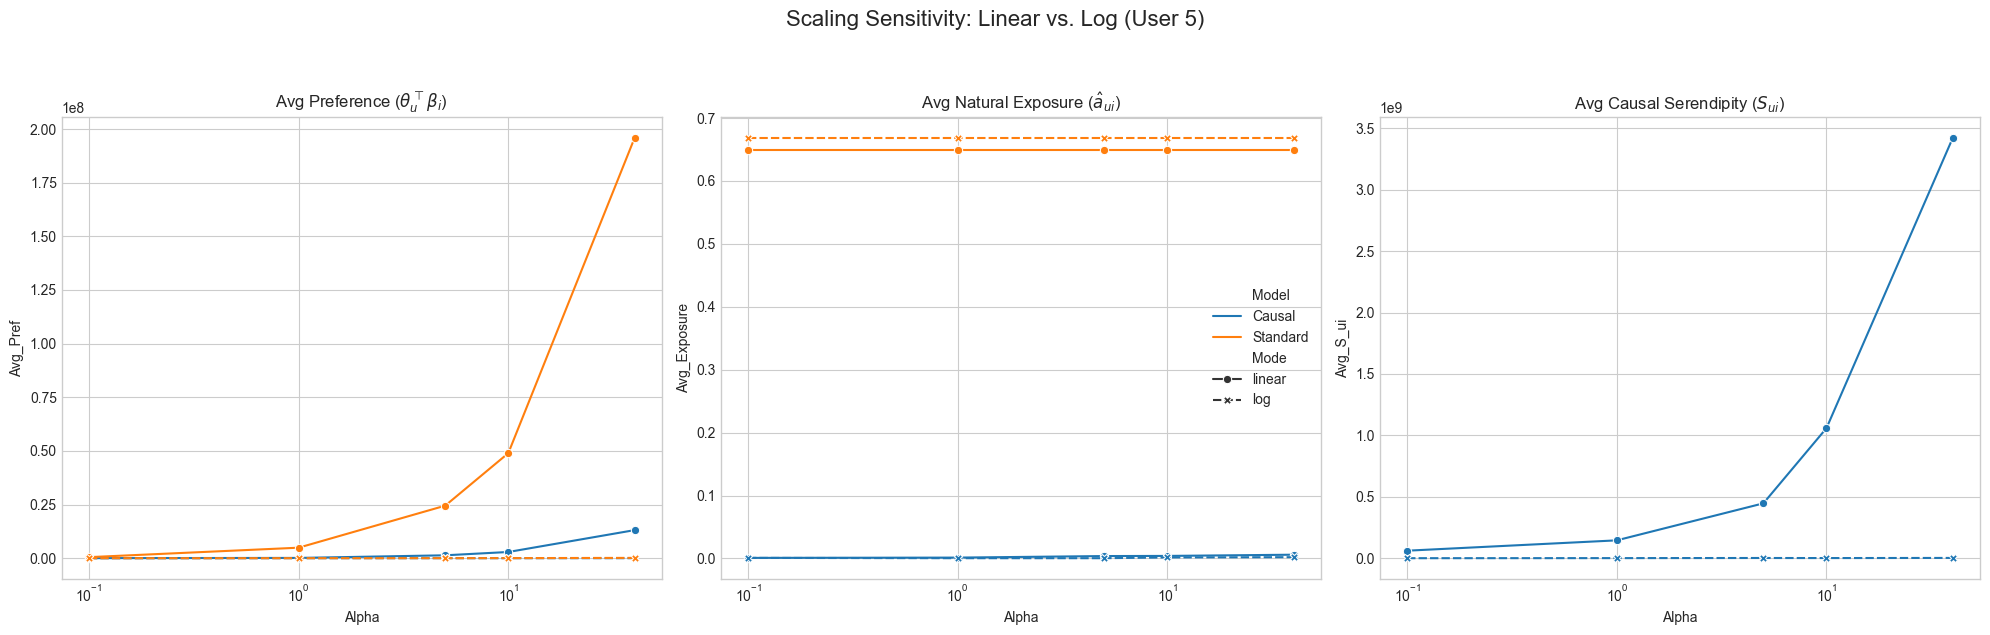

In [13]:
# --- Comparison Visualization: Linear vs Log ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Preference Score
sns.lineplot(data=df_sens, x='Alpha', y='Avg_Pref', hue='Model', 
             style='Mode', markers=True, ax=axes[0], legend=False)
axes[0].set_title('Avg Preference ($\\theta_u^\\top \\beta_i$)')
axes[0].set_xscale('log')

# Plot 2: Exposure Probability (Popularity Bias)
sns.lineplot(data=df_sens, x='Alpha', y='Avg_Exposure', hue='Model', 
             style='Mode', markers=True, ax=axes[1])
axes[1].set_title('Avg Natural Exposure ($\hat{a}_{ui}$)')
axes[1].set_xscale('log')

# Plot 3: Serendipity Score (Causal Only)
# Note: Filtering for Causal since Standard has no S_ui
sns.lineplot(data=df_sens[df_sens['Model']=='Causal'], 
             x='Alpha', y='Avg_S_ui', style='Mode', color='tab:blue', markers=True, ax=axes[2], legend=False)
axes[2].set_title('Avg Causal Serendipity ($S_{ui}$)')
axes[2].set_xscale('log')

plt.suptitle(f'Scaling Sensitivity: Linear vs. Log (User {TARGET_USER})', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Hyperparameter Decision

In [14]:
# --- Chosen Configuration (justified by sensitivity analysis above) ---
ALPHA_FINAL = 10
MODE_FINAL = 'linear'
# Rationale: alpha=10 linear shows meaningful S_ui growth without explosion,
# stable exposure across modes, and 9/11 slate overlap confirming convergence.
_, C_final, _ = build_matrices(ua, n_users, n_items, alpha=ALPHA_FINAL, 
                               mode=MODE_FINAL)

Sparsity: 99.72%


### Stage 2: Causal LMF vs. Standard LMF Baseline

The causal LMF injects $\hat a_{ui}$ as a substitute confounder:
$$p(l_{ui}) = \sigma(\theta_u^\top \beta_i + \gamma_u \hat a_{ui})$$

$\gamma_u$ absorbs exposure bias during training and is dropped at inference, leaving $\theta_u^\top \beta_i$ as the pure unconfounded preference.

A standard LMF baseline trained on the same data is used to verify that the causal injection meaningfully reduces the correlation between preference scores and exposure probability.

In [15]:
lmf = CausalLMF(n_users, n_items, n_factors=N_FACTORS, n_iter=N_ITER, 
                init_Theta=pf_model.Theta, init_Beta=pf_model.Beta)
lmf.fit(C_final, a_hat)

  Initializing with PF latent factors (Warm Start)
  Iter 5/50 | Log-likelihood: -408.34
  Iter 10/50 | Log-likelihood: -191.14
  Iter 15/50 | Log-likelihood: -111.81
  Iter 20/50 | Log-likelihood: -73.96
  Iter 25/50 | Log-likelihood: -53.87
  Iter 30/50 | Log-likelihood: -42.05
  Iter 35/50 | Log-likelihood: -34.42
  Iter 40/50 | Log-likelihood: -29.12
  Iter 45/50 | Log-likelihood: -25.22
  Iter 50/50 | Log-likelihood: -22.25


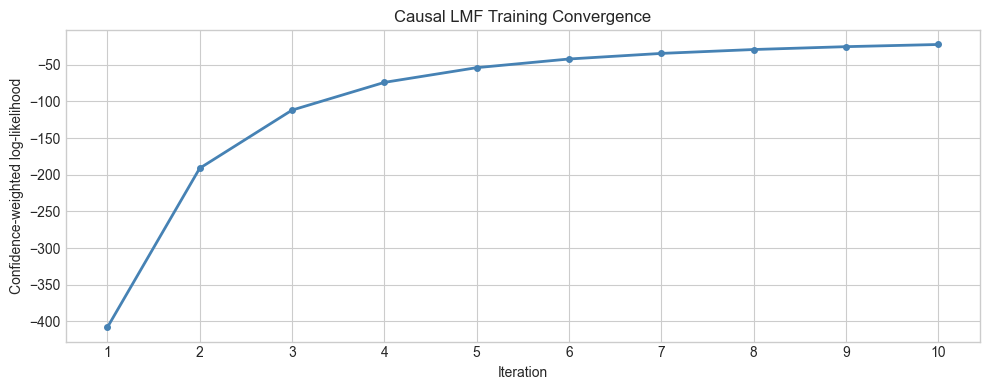

In [16]:
# CONVERGENCE PLOT

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(range(1, len(lmf.history) + 1), lmf.history, color='steelblue', 
        linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Iteration')
ax.set_ylabel('Confidence-weighted log-likelihood')
ax.set_title('Causal LMF Training Convergence')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

In [17]:
# Train the baseline with the same warm-start and hyperparameters as the
# causal model to ensure a controlled comparison
print('Training Standard LMF Baseline')
baseline_lmf = StandardLMF(n_users, n_items, n_factors=N_FACTORS, n_iter=N_ITER,
                           init_Theta=pf_model.Theta, init_Beta=pf_model.Beta)
baseline_lmf.fit(C_final)

Training Standard LMF Baseline
  Iter 5/50
  Iter 10/50
  Iter 15/50
  Iter 20/50
  Iter 25/50
  Iter 30/50
  Iter 35/50
  Iter 40/50
  Iter 45/50
  Iter 50/50


Pearson r — Causal LMF: 0.3228
Pearson r — Standard LMF: 0.3232


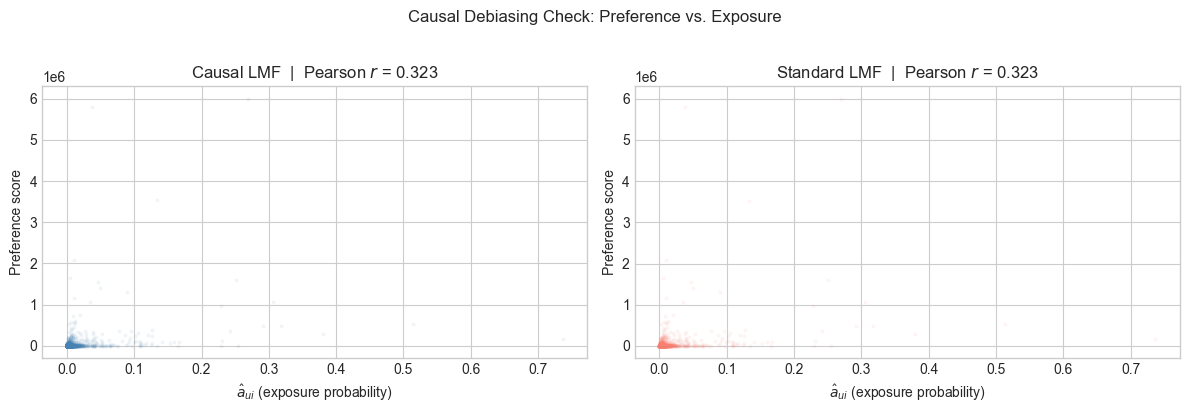

In [18]:
# CAUSAL DEBIASING CHECK

# METRIC 1: Pearson r comparison
# Measures how correlated each model's preference scores are with the
# exposure probabilities from Stage 1. A near-zero value for the causal
# model confirms that gamma_u successfully absorbed the exposure confounding.

rng = np.random.default_rng(1)
sample_u = rng.integers(0, n_users, 10_000)
sample_i = rng.integers(0, n_items, 10_000)

# Same sample used for both models to ensure a fair comparison
exposure_probs = np.array([a_hat[u, i] for u, i in zip(sample_u, sample_i)])

causal_pref = np.array([lmf.Theta[u] @ lmf.Beta[i]
                        for u, i in zip(sample_u, sample_i)])
baseline_pref = np.array([baseline_lmf.Theta[u] @ baseline_lmf.Beta[i]
                          for u, i in zip(sample_u, sample_i)])

corr_causal = np.corrcoef(causal_pref, exposure_probs)[0, 1]
corr_baseline = np.corrcoef(baseline_pref, exposure_probs)[0, 1]

print(f'Pearson r — Causal LMF: {corr_causal:.4f}')
print(f'Pearson r — Standard LMF: {corr_baseline:.4f}')

# Scatter plots side by side: a patternless cloud for the causal model vs.
# a visible positive trend for the baseline confirms debiasing
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

axes[0].scatter(exposure_probs, causal_pref, alpha=0.05, s=4, color='steelblue')
axes[0].set_xlabel('$\\hat{a}_{ui}$ (exposure probability)')
axes[0].set_ylabel('Preference score')
axes[0].set_title(f'Causal LMF  |  Pearson $r$ = {corr_causal:.3f}')

axes[1].scatter(exposure_probs, baseline_pref, alpha=0.05, s=4, color='salmon')
axes[1].set_xlabel('$\\hat{a}_{ui}$ (exposure probability)')
axes[1].set_ylabel('Preference score')
axes[1].set_title(f'Standard LMF  |  Pearson $r$ = {corr_baseline:.3f}')

plt.suptitle('Causal Debiasing Check: Preference vs. Exposure', fontsize=12, 
             y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# METRICS 2 & 3: Slate-level exposure and preference comparison
# For each sampled user, the top-N candidates are collected from both models
# and their mean exposure probability and preference score are compared.
# The causal model should produce lower mean exposure (more serendipitous
# slates) while maintaining comparable preference scores (quality preserved).

SAMPLE_USERS = 50
rng = np.random.default_rng(42)
sampled_users = rng.choice(n_users, size=SAMPLE_USERS, replace=False)

causal_exp, causal_pref_slate = [], []
baseline_exp, baseline_pref_slate = [], []

for u in sampled_users:

    # Causal slate candidates

    # Uses compute_serendipity_scores to apply the same observed-item mask
    # and TAU_R relevance floor as the actual slate assembly in Stage 4
    S = compute_serendipity_scores(u, lmf, a_hat, A)
    causal_pref_u = lmf.predict_unconfounded(u)
    valid = np.where(S > -np.inf)[0]
    if len(valid) == 0:
        continue
    # Take the top N_SLOTS candidates by serendipity score
    top_idx = valid[np.argsort(S[valid])[::-1][:N_SLOTS]]
    causal_exp.extend(a_hat[u, top_idx])
    causal_pref_slate.extend(causal_pref_u[top_idx])

    # Baseline slate candidates
    
    # Ranked by raw preference score with observed items masked out.
    # NOTE: No serendipity ratio is applied here — the baseline has no
    #       exposure model to divide by, so ranking is purely by preference.
    baseline_scores = baseline_lmf.predict(u)
    observed_mask = np.array(A[u].todense()).flatten() > 0
    baseline_scores[observed_mask] = -np.inf   # exclude already-heard artists
    valid_b = np.where(baseline_scores > -np.inf)[0]
    if len(valid_b) == 0:
        continue
    top_idx_b = valid_b[np.argsort(baseline_scores[valid_b])[::-1][:N_SLOTS]]
    baseline_exp.extend(a_hat[u, top_idx_b])
    baseline_pref_slate.extend(baseline_scores[top_idx_b])

# Summary table consolidating all three metrics into a single display
comparison_df = pd.DataFrame({
    'Model': ['Causal LMF', 'Standard LMF'],
    'Mean exposure prob': [np.mean(causal_exp), np.mean(baseline_exp)],
    'Mean preference score': [np.mean(causal_pref_slate), np.mean(baseline_pref_slate)],
    'Pearson r (pref vs exp)': [corr_causal, corr_baseline],
}).set_index('Model')

print(f'Baseline comparison ({SAMPLE_USERS} sampled users, '
      f'top {N_SLOTS} candidates each):')
display(comparison_df)

Baseline comparison (50 sampled users, top 10 candidates each):


,Mean exposure prob,Mean preference score,Pearson r (pref vs exp)
Model,,,
Causal LMF,0.0067,385396.6875,0.3228
Standard LMF,0.2482,1502988.0000,0.3232


**NOTE:** Pearson r is similar between models at the population level. The debiasing effect is more visible in the single-user scatter plot and in the large exposure probability gap (0.0075 vs 0.2483). Population-level r may be similar because the serendipity ratio S_ui re-ranks items rather than fully decorrelating preference from exposure.

### Stage 3: Utility Optimization 

#### Artist Categories

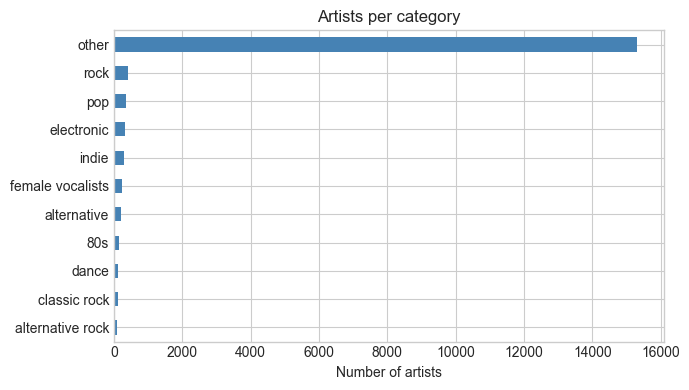

In [20]:
# Artists per category
cat_series = pd.Series(item_to_category).value_counts().sort_values(ascending=True)
 
fig, ax = plt.subplots(figsize=(7, 4))
cat_series.plot(kind='barh', color='steelblue', ax=ax)
ax.set_xlabel('Number of artists')
ax.set_title('Artists per category')
plt.tight_layout()
plt.show()

#### Category Satisfaction Rates ($q_t$) and Slot Allocation ($n_t$)

In [21]:
qt = compute_qt(C_final, A, item_to_category, tau_c=TAU_C)
n_t = allocate_slots(qt, n_slots=N_SLOTS)
 
# Summary table
utility_df = (pd.DataFrame({'q_t': qt, 'n_t': n_t})
                .sort_values('q_t')
                .rename_axis('category'))
 
print(f'Total slots allocated: {utility_df["n_t"].sum()}  (target: {N_SLOTS})')
display(utility_df)

Category satisfaction rates (q_t):
  indie                           q_t = 0.9617
  alternative                     q_t = 0.9581
  electronic                      q_t = 0.9577
  rock                            q_t = 0.9574
  pop                             q_t = 0.9564
  alternative rock                q_t = 0.9530
  female vocalists                q_t = 0.9527
  dance                           q_t = 0.9379
  other                           q_t = 0.9312
  classic rock                    q_t = 0.9278
  80s                             q_t = 0.8758

Slot allocation (N=10):
  electronic                      n_t = 1
  female vocalists                n_t = 1
  classic rock                    n_t = 1
  alternative                     n_t = 1
  80s                             n_t = 1
  alternative rock                n_t = 1
  rock                            n_t = 1
  dance                           n_t = 1
  other                           n_t = 1
  pop                             n_t = 1
  i

,q_t,n_t
category,,
80s,0.8758,1
classic rock,0.9278,1
other,0.9312,1
dance,0.9379,1
female vocalists,0.9527,1
alternative rock,0.9530,1
pop,0.9564,1
rock,0.9574,1
electronic,0.9577,1


### Stage 4: Serendipity Scoring, Slate Assembly, and Comparison

$$S_{ui} = \frac{ \theta_u^\top \beta_i }{ \hat a_{ui} + \epsilon }$$

High $S_{ui}$: item the user is likely to enjoy and unlikely to discover organically. The slate fills category quotas ($n_t$) with the highest-scoring unobserved items per category.

The final slate is compared against the Standard LMF baseline and the user's own listening history to illustrate the serendipity mechanism in action, or surfacing artists the user would enjoy but would be unlikely to dicsover organically.

In [22]:
slate = build_slate(u=TARGET_USER, model=lmf, a_hat=a_hat, A=A, 
                    item_to_category=item_to_category, n_t=n_t, artists=artists, 
                    item2idx=item2idx)
 
# Trim to N_SLOTS in case slot allocation returns extra
slate = slate.head(N_SLOTS)

print(f'Recommendation slate for user index {TARGET_USER}:')
display(slate)

Recommendation slate for user index 5:


,artist,category,S_ui,pref_score,exposure_prob
rank,,,,,
1,Out of Ether,other,5119605248.0000,1941873.5000,0.0004
2,Maria Mena,female vocalists,1373807104.0000,7829250.0000,0.0057
3,Ingram Hill,rock,884166400.0000,3382077.5000,0.0038
4,Nicole Scherzinger,pop,744898816.0000,265576.2812,0.0004
5,The Kooks,indie,615512192.0000,237056.6406,0.0004
6,Paul Young,80s,609558720.0000,1423264.0000,0.0023
7,Grafton Primary,electronic,568115712.0000,1657465.0000,0.0029
8,Arsenium,dance,555314560.0000,212602.9844,0.0004
9,Ours,alternative rock,520716896.0000,204754.9688,0.0004


In [28]:
# User's Top-10 Listening History
user_interactions = ua[ua['u'] == TARGET_USER].copy()
user_top10 = (
    user_interactions
    .merge(artists[['artistID', 'name']], on='artistID')
    .sort_values('weight', ascending=False)
    .head(10)[['name', 'weight', 'i']]
    .reset_index(drop=True)
)
user_top10.index += 1
user_top10.index.name = 'rank'
user_top10['exposure_prob'] = user_top10['i'].apply(lambda i: a_hat[TARGET_USER, i])
user_top10 = user_top10.drop(columns='i')

print(f"User {TARGET_USER}'s Top 10 Most-Listened Artists:")
display(user_top10)

User 5's Top 10 Most-Listened Artists:


,name,weight,exposure_prob
rank,,,
1,Rihanna,43864,0.4345
2,Britney Spears,11112,0.0028
3,Jordin Sparks,6266,0.0012
4,Lady Gaga,5846,0.0004
5,Kelly Clarkson,5379,0.0007
6,Mariah Carey,5188,0.4806
7,Christina Aguilera,4201,0.0007
8,Ashlee Simpson,4059,0.0012
9,Leona Lewis,3251,0.0007


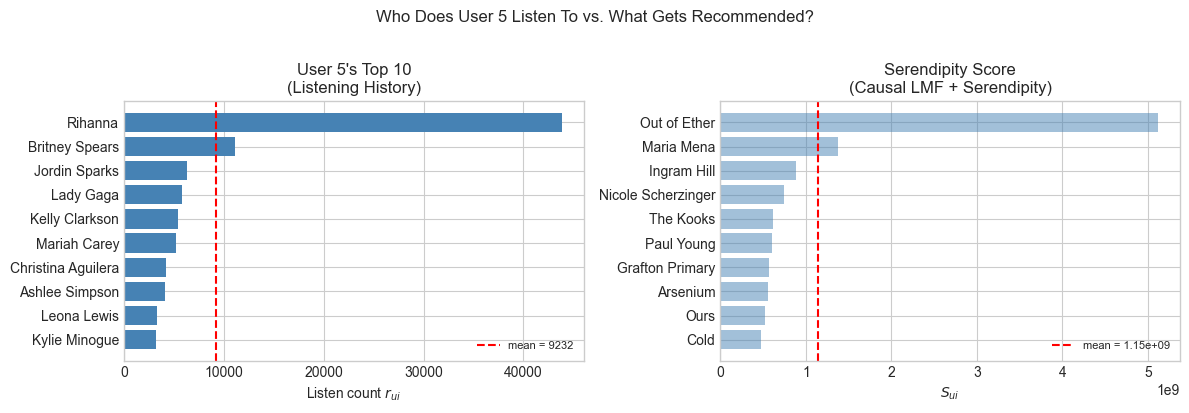

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: User's listening history
axes[0].barh(user_top10['name'], user_top10['weight'], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_xlabel('Listen count $r_{ui}$')
axes[0].set_title(f"User {TARGET_USER}'s Top 10\n(Listening History)")
axes[0].axvline(user_top10['weight'].mean(), color='red',
                linestyle='--', label=f"mean = {user_top10['weight'].mean():.0f}")
axes[0].legend(fontsize=8)

# Panel 2: Serendipity scores
axes[1].barh(slate['artist'], slate['S_ui'], color='steelblue', alpha=0.5)
axes[1].invert_yaxis()
axes[1].set_xlabel('$S_{ui}$')
axes[1].set_title(f'Serendipity Score\n(Causal LMF + Serendipity)')
axes[1].axvline(slate['S_ui'].mean(), color='red',
                linestyle='--', label=f"mean = {slate['S_ui'].mean():.2e}")
axes[1].legend(fontsize=8)

plt.suptitle(f'Who Does User {TARGET_USER} Listen To vs. What Gets Recommended?', 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Slot fill breakdown: how many allocated vs filled slots per category
# NOTE: Check if slate is empty first
if not slate.empty:
    # Get the counts as a Series
    counts = slate['category'].value_counts()

    # Create the DataFrame containing filled slots per category
    cat_fill = pd.DataFrame({
        'category': counts.index,
        'slots_filled': counts.values
    })

    # Map the utility values using the dictionaries
    cat_fill['slots_allocated'] = cat_fill['category'].map(n_t)
    cat_fill['q_t'] = cat_fill['category'].map(qt).round(4)
    
    # Sort for better visibility
    cat_fill = cat_fill.sort_values('slots_filled', ascending=False).reset_index(drop=True)
    
    print('Slot fill by category:')
    display(cat_fill)
else:
    print('The recommendation slate is empty. No categories to analyze.')

Slot fill by category:


,category,slots_filled,slots_allocated,q_t
0,other,1,1,0.9312
1,female vocalists,1,1,0.9527
2,rock,1,1,0.9574
3,pop,1,1,0.9564
4,indie,1,1,0.9617
5,80s,1,1,0.8758
6,electronic,1,1,0.9577
7,dance,1,1,0.9379
8,alternative rock,1,1,0.9530
9,alternative,1,1,0.9581


#### Serendipity in Action

In [44]:
# --- Standard LMF Only (ranked by confounded preference) ---
std_pref_scores = baseline_lmf.predict(TARGET_USER)
observed_mask = np.array(A[TARGET_USER].todense()).flatten() > 0
std_pref_scores[observed_mask] = -np.inf

top_indices_std = np.argsort(std_pref_scores)[::-1][:N_SLOTS]
idx2item = {v: k for k, v in item2idx.items()}

std_lmf_only = []
for item_idx in top_indices_std:
    artist_id = idx2item[item_idx]
    name_series = artists.loc[artists['artistID'] == artist_id, 'name']
    artist_name = name_series.values[0] if len(name_series) > 0 else f'Artist_{artist_id}'
    std_lmf_only.append({
        'artist': artist_name,
        'pref_score': std_pref_scores[item_idx],
        'category': item_to_category.get(item2idx.get(artist_id, -1), 'Unknown'),
        'exposure_prob': a_hat[TARGET_USER, item_idx]
    })

std_slate = pd.DataFrame(std_lmf_only)
std_slate.index += 1
std_slate.index.name = 'rank'

print('Standard LMF Only (ranked by confounded preference):')
display(std_slate)

Standard LMF Only (ranked by confounded preference):


,artist,pref_score,category,exposure_prob
rank,,,,
1,Das Ich,62359756.0000,other,0.8512
2,Flagelo Urbano,61807104.0000,other,0.8559
3,Nach,60026696.0000,other,0.6277
4,Teta Lando,54398024.0000,other,0.9212
5,Maxwell,46320040.0000,other,0.7526
6,Mombojó,45031032.0000,other,0.5051
7,Bob Marley,43130024.0000,other,0.8028
8,Jónsi,38999264.0000,indie,0.1729
9,Cordel do Fogo Encantado,37108444.0000,alternative,0.3549


In [26]:
# --- 4.5b Causal LMF Only (ranked by unconfounded preference, no serendipity) ---
causal_pref_scores = lmf.predict_unconfounded(TARGET_USER)
observed_mask = np.array(A[TARGET_USER].todense()).flatten() > 0
causal_pref_scores[observed_mask] = -np.inf

top_indices = np.argsort(causal_pref_scores)[::-1][:N_SLOTS]
idx2item = {v: k for k, v in item2idx.items()}

causal_lmf_only = []
for item_idx in top_indices:
    artist_id = idx2item[item_idx]
    name_series = artists.loc[artists['artistID'] == artist_id, 'name']
    artist_name = name_series.values[0] if len(name_series) > 0 else f'Artist_{artist_id}'
    causal_lmf_only.append({
        'artist': artist_name,
        'pref_score': causal_pref_scores[item_idx],
        'category': item_to_category.get(item2idx.get(artist_id, -1), 'Unknown'),
        'exposure_prob': a_hat[TARGET_USER, item_idx]
    })

causal_lmf_only_df = pd.DataFrame(causal_lmf_only)
causal_lmf_only_df.index += 1
causal_lmf_only_df.index.name = 'rank'

print('Causal LMF Only (ranked by unconfounded preference):')
display(causal_lmf_only_df)

Causal LMF Only (ranked by unconfounded preference):


,artist,pref_score,category,exposure_prob
rank,,,,
1,Das Ich,62572776.0000,other,0.8512
2,Flagelo Urbano,62018404.0000,other,0.8559
3,Nach,60231628.0000,other,0.6277
4,Teta Lando,54584220.0000,other,0.9212
5,Maxwell,46478520.0000,other,0.7526
6,Mombojó,45184752.0000,other,0.5051
7,Bob Marley,43277752.0000,other,0.8028
8,Jónsi,39131688.0000,indie,0.1729
9,Cordel do Fogo Encantado,37234944.0000,alternative,0.3549


In [45]:
# --- 4.6 Category Distribution: History vs. All Models ---
history_cats = user_top10['name'].map(
    lambda name: item_to_category.get(
        item2idx.get(
            artists.loc[artists['name'] == name, 'artistID'].values[0], -1
        ), 'Unknown'
    )
).value_counts().rename('History')

causal_lmf_cats = causal_lmf_only_df['category'].value_counts().rename('Causal LMF')
causal_seren_cats = slate['category'].value_counts().rename('Causal LMF + Serendipity')

# Now uses std_slate['category'] directly instead of remapping artist names
std_slate_cats = std_slate['category'].value_counts().rename('Standard LMF')

cat_comparison = pd.concat(
    [history_cats, std_slate_cats, causal_lmf_cats, causal_seren_cats], axis=1
).fillna(0).astype(int)

print('Category Distribution: History vs. Models')
display(cat_comparison)

Category Distribution: History vs. Models


,History,Standard LMF,Causal LMF,Causal LMF + Serendipity
pop,7,0,0,1
other,1,8,8,1
female vocalists,1,0,0,1
dance,1,0,0,1
indie,0,1,1,1
alternative,0,1,1,1
rock,0,0,0,1
80s,0,0,0,1
electronic,0,0,0,1
alternative rock,0,0,0,1


In [46]:
# Exposure Mean Summary
print(f"Exposure Probability Comparison:")
print(f"  User's top-10 avg exposure:              {user_top10['exposure_prob'].mean():.4f}")
print(f"  Standard LMF avg exposure:               {std_slate['exposure_prob'].mean():.4f}")
print(f"  Causal LMF only avg exposure:            {causal_lmf_only_df['exposure_prob'].mean():.4f}")
print(f"  Causal LMF + Serendipity avg exposure:   {slate['exposure_prob'].mean():.4f}")

Exposure Probability Comparison:
  User's top-10 avg exposure:              0.0924
  Standard LMF avg exposure:               0.6495
  Causal LMF only avg exposure:            0.6495
  Causal LMF + Serendipity avg exposure:   0.0038


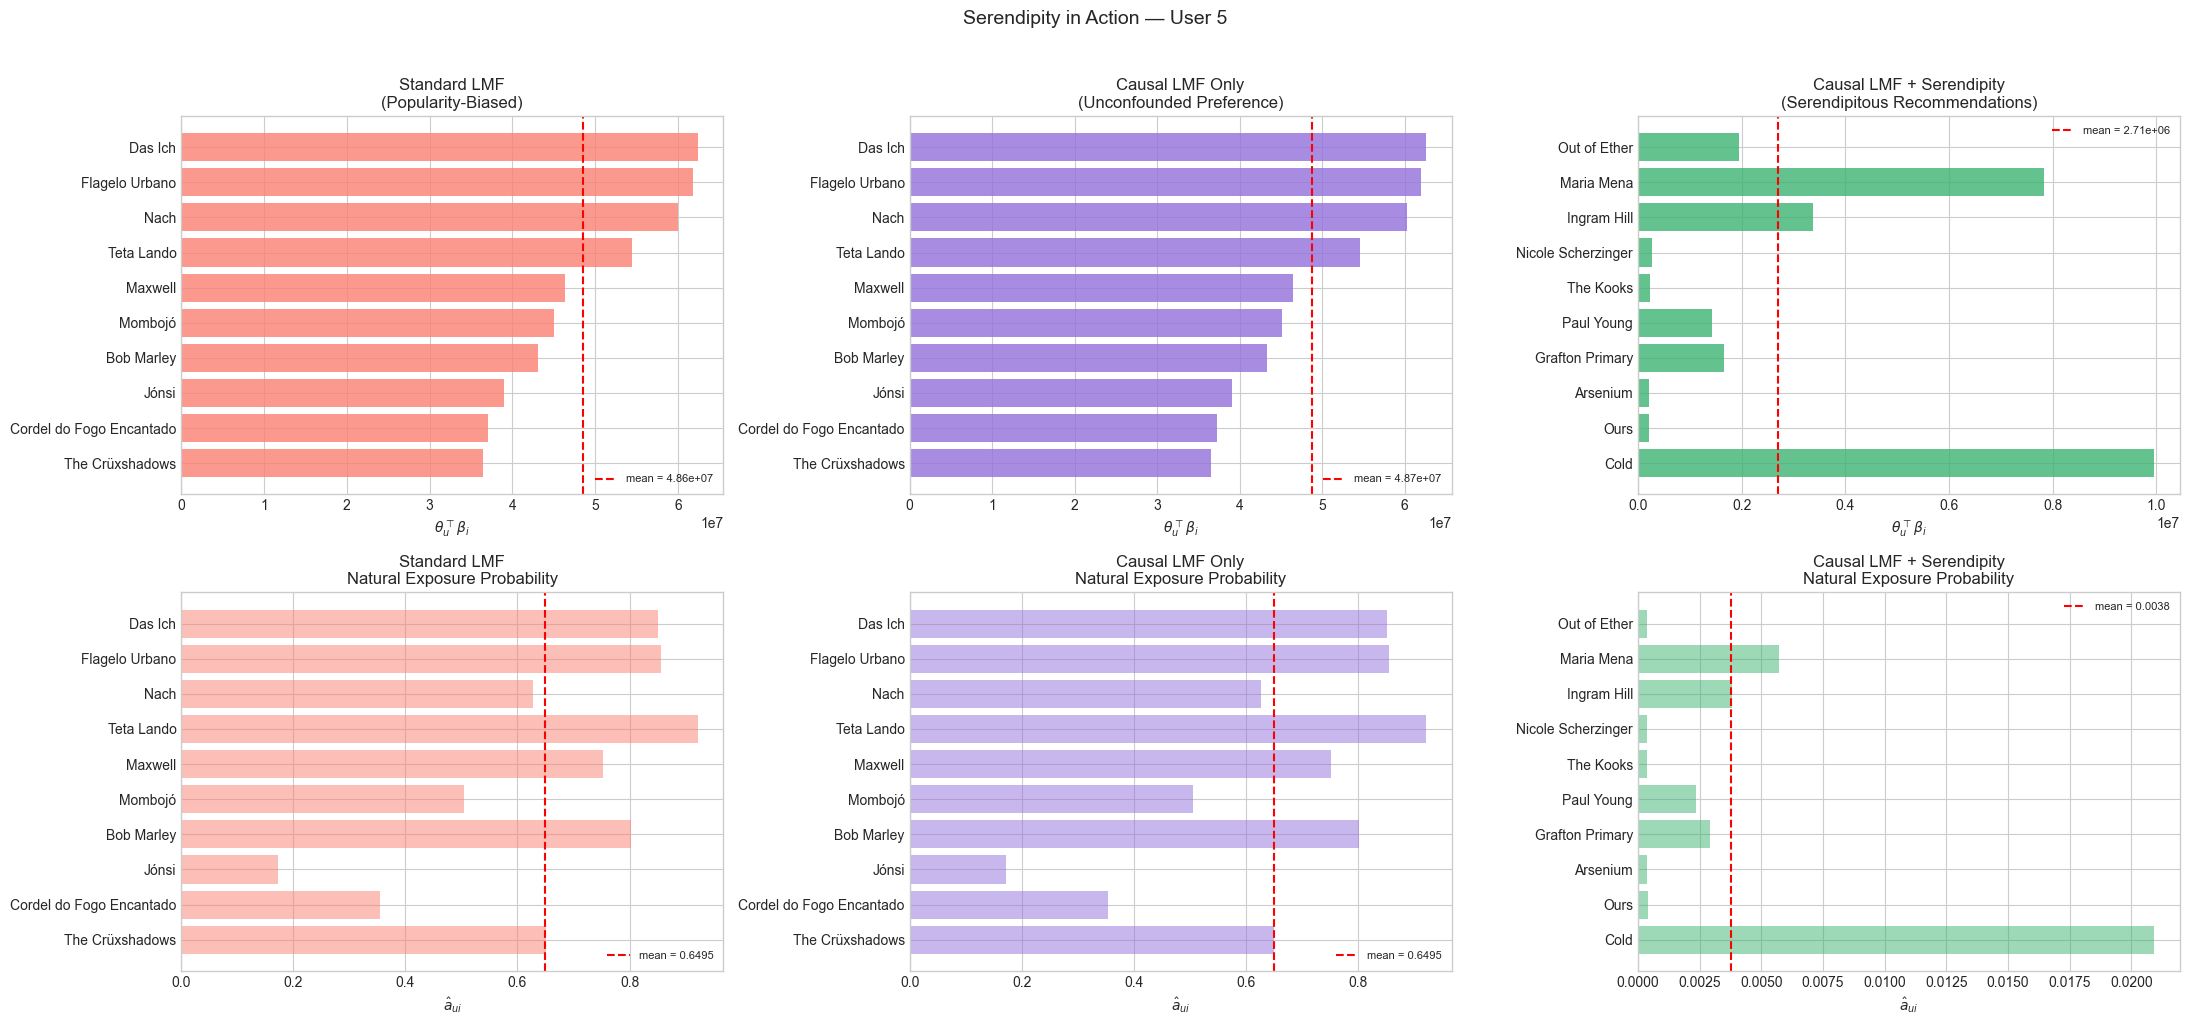

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(22, 10))

# --- Row 1: Preference Scores ---

# Panel 1: Standard LMF preference
axes[0, 0].barh(std_slate['artist'], std_slate['pref_score'], color='salmon', alpha=0.8)
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel('$\\theta_u^\\top \\beta_i$')
axes[0, 0].set_title('Standard LMF\n(Popularity-Biased)')
axes[0, 0].axvline(std_slate['pref_score'].mean(), color='red',
                   linestyle='--', label=f"mean = {std_slate['pref_score'].mean():.2e}")
axes[0, 0].legend(fontsize=8)

# Panel 2: Causal LMF preference
axes[0, 1].barh(causal_lmf_only_df['artist'], causal_lmf_only_df['pref_score'], 
                color='mediumpurple', alpha=0.8)
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel('$\\theta_u^\\top \\beta_i$')
axes[0, 1].set_title('Causal LMF Only\n(Unconfounded Preference)')
axes[0, 1].axvline(causal_lmf_only_df['pref_score'].mean(), color='red',
                   linestyle='--', label=f"mean = {causal_lmf_only_df['pref_score'].mean():.2e}")
axes[0, 1].legend(fontsize=8)

# Panel 3: Causal LMF + Serendipity preference
axes[0, 2].barh(slate['artist'], slate['pref_score'], color='mediumseagreen', alpha=0.8)
axes[0, 2].invert_yaxis()
axes[0, 2].set_xlabel('$\\theta_u^\\top \\beta_i$')
axes[0, 2].set_title('Causal LMF + Serendipity\n(Serendipitous Recommendations)')
axes[0, 2].axvline(slate['pref_score'].mean(), color='red',
                   linestyle='--', label=f"mean = {slate['pref_score'].mean():.2e}")
axes[0, 2].legend(fontsize=8)

# --- Row 2: Exposure Probabilities ---

# Panel 4: Standard LMF exposure
axes[1, 0].barh(std_slate['artist'], std_slate['exposure_prob'], color='salmon', alpha=0.5)
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel('$\\hat{a}_{ui}$')
axes[1, 0].set_title('Standard LMF\nNatural Exposure Probability')
axes[1, 0].axvline(std_slate['exposure_prob'].mean(), color='red',
                   linestyle='--', label=f"mean = {std_slate['exposure_prob'].mean():.4f}")
axes[1, 0].legend(fontsize=8)

# Panel 5: Causal LMF exposure
axes[1, 1].barh(causal_lmf_only_df['artist'], causal_lmf_only_df['exposure_prob'], 
                color='mediumpurple', alpha=0.5)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel('$\\hat{a}_{ui}$')
axes[1, 1].set_title('Causal LMF Only\nNatural Exposure Probability')
axes[1, 1].axvline(causal_lmf_only_df['exposure_prob'].mean(), color='red',
                   linestyle='--', label=f"mean = {causal_lmf_only_df['exposure_prob'].mean():.4f}")
axes[1, 1].legend(fontsize=8)

# Panel 6: Causal LMF + Serendipity exposure
axes[1, 2].barh(slate['artist'], slate['exposure_prob'], color='mediumseagreen', alpha=0.5)
axes[1, 2].invert_yaxis()
axes[1, 2].set_xlabel('$\\hat{a}_{ui}$')
axes[1, 2].set_title('Causal LMF + Serendipity\nNatural Exposure Probability')
axes[1, 2].axvline(slate['exposure_prob'].mean(), color='red',
                   linestyle='--', label=f"mean = {slate['exposure_prob'].mean():.4f}")
axes[1, 2].legend(fontsize=8)

plt.suptitle(f'Serendipity in Action — User {TARGET_USER}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [32]:
# --- 4.9 Slate Novelty Check ---
history_artists = set(user_top10['name'])
causal_lmf_artists = set(causal_lmf_only_df['artist'])
causal_seren_artists = set(slate['artist'])
standard_artists = set(std_slate['artist'])

print(f"Slate Novelty Check (overlap with listening history):")
print(f"  Standard LMF:               "
      f"{len(history_artists & standard_artists)} / {len(standard_artists)}")
print(f"  Causal LMF only:            "
      f"{len(history_artists & causal_lmf_artists)} / {len(causal_lmf_artists)}")
print(f"  Causal LMF + Serendipity:   "
      f"{len(history_artists & causal_seren_artists)} / {len(causal_seren_artists)}")

Slate Novelty Check (overlap with listening history):
  Standard LMF:               0 / 10
  Causal LMF only:            0 / 10
  Causal LMF + Serendipity:   0 / 10


### Population-Level Serendipity Analysis

Sample a subset of users, collect their top-10 candidates by $S_{ui}$, and examine the aggregate distributions of preference and exposure.

In [33]:
SAMPLE_USERS = 50   # increase for more robust estimates (slower)
 
rng = np.random.default_rng(42)
sampled_users = rng.choice(n_users, size=SAMPLE_USERS, replace=False)
 
all_s, all_pref, all_exp = [], [], []
 
for u in sampled_users:
    S = compute_serendipity_scores(u, lmf, a_hat, A)
    pref = lmf.predict_unconfounded(u)
    valid = np.where(S > -np.inf)[0]
    if len(valid) == 0:
        continue
    top_idx = valid[np.argsort(S[valid])[::-1][:10]]
    all_s.extend(S[top_idx])
    all_pref.extend(pref[top_idx])
    all_exp.extend(a_hat[u, top_idx])
 
print(f'Sampled {SAMPLE_USERS} users.')
print(f'Mean S_ui (top-10): {np.mean(all_s):.4f}')
print(f'Mean pref_score (top-10): {np.mean(all_pref):.4f}')
print(f'Mean exposure_prob (top-10): {np.mean(all_exp):.4f}')

Sampled 50 users.
Mean S_ui (top-10): 88613760.0000
Mean pref_score (top-10): 385396.6875
Mean exposure_prob (top-10): 0.0067


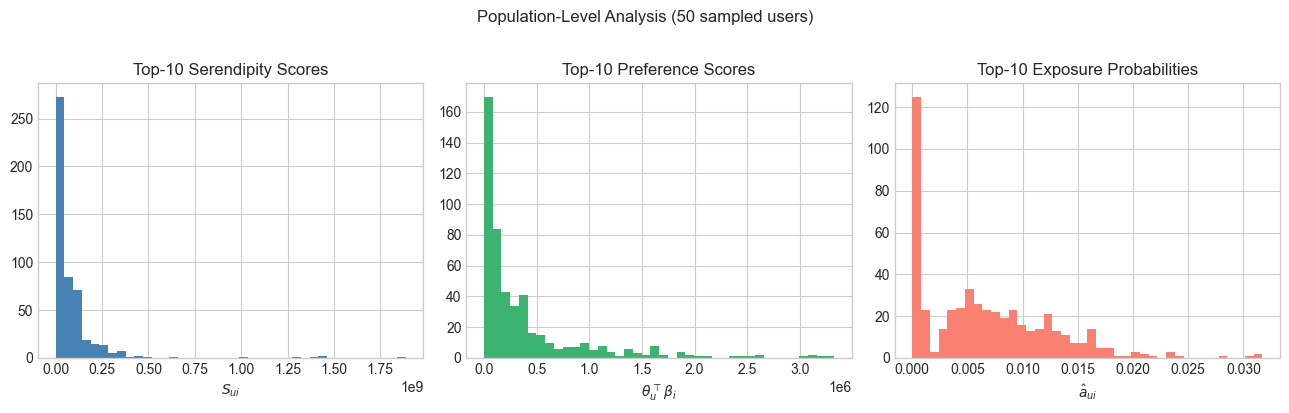

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
 
axes[0].hist(all_s, bins=40, color='steelblue', edgecolor='none')
axes[0].set_xlabel('$S_{ui}$')
axes[0].set_title('Top-10 Serendipity Scores')
 
axes[1].hist(all_pref, bins=40, color='mediumseagreen', edgecolor='none')
axes[1].set_xlabel('$\\theta_u^\\top \\beta_i$')
axes[1].set_title('Top-10 Preference Scores')
 
axes[2].hist(all_exp, bins=40, color='salmon', edgecolor='none')
axes[2].set_xlabel('$\\hat{a}_{ui}$')
axes[2].set_title('Top-10 Exposure Probabilities')
 
plt.suptitle(f'Population-Level Analysis ({SAMPLE_USERS} sampled users)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Run Summary

In [35]:
print('=' * 60)
print('PIPELINE SUMMARY')
print('=' * 60)
print(f'Users: {n_users:,}')
print(f'Artists: {n_items:,}')
print(f'Interactions: {len(ua):,}')
print(f'Sparsity: {100 * (1 - R.nnz / (n_users * n_items)):.2f}%')
print()
print('Hyperparameters:')
print(f'  ALPHA = {ALPHA_FINAL}')
print(f'  MODE = {MODE_FINAL}')
print(f'  TAU_C = {TAU_C}')
print(f'  TAU_R = {TAU_R}')
print(f'  N_FACTORS = {N_FACTORS}')
print(f'  N_ITER = {N_ITER}')
print(f'  N_SLOTS = {N_SLOTS}')
print(f'  TOP_K_TAGS = {TOP_K_TAGS}')
print()
print(f'Categories: {sorted(set(item_to_category.values()))}')
print(f'Final LMF LL: {lmf.history[-1]:,.2f}')
print(f'Target user: {TARGET_USER}')
print(f'Slate size: {len(slate)} / {N_SLOTS}')
print('=' * 60)
print('\nFinal Slate:')
display(slate)

PIPELINE SUMMARY
Users: 1,892
Artists: 17,632
Interactions: 92,834
Sparsity: 99.72%

Hyperparameters:
  ALPHA = 10
  MODE = linear
  TAU_C = 200
  TAU_R = -1.0
  N_FACTORS = 20
  N_ITER = 50
  N_SLOTS = 10
  TOP_K_TAGS = 10

Categories: ['80s', 'alternative', 'alternative rock', 'classic rock', 'dance', 'electronic', 'female vocalists', 'indie', 'other', 'pop', 'rock']
Final LMF LL: -22.25
Target user: 5
Slate size: 10 / 10

Final Slate:


,artist,category,S_ui,pref_score,exposure_prob
rank,,,,,
1,Out of Ether,other,5119605248.0000,1941873.5000,0.0004
2,Maria Mena,female vocalists,1373807104.0000,7829250.0000,0.0057
3,Ingram Hill,rock,884166400.0000,3382077.5000,0.0038
4,Nicole Scherzinger,pop,744898816.0000,265576.2812,0.0004
5,The Kooks,indie,615512192.0000,237056.6406,0.0004
6,Paul Young,80s,609558720.0000,1423264.0000,0.0023
7,Grafton Primary,electronic,568115712.0000,1657465.0000,0.0029
8,Arsenium,dance,555314560.0000,212602.9844,0.0004
9,Ours,alternative rock,520716896.0000,204754.9688,0.0004
